In [415]:
import pandas as pd
log_path = r'04_08\prueba_05.csv'
df_log = pd.read_csv(log_path, dtype=str)
df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,1785880399079,BB14200000000000,54CBAA01,1183A033,592D0000,12000000,4C000000,FF720000,00000000,00000000,00000000,58FCFFFF,BB1420000000000054CBAA011183A033592D0000120000...
1,1785880399079,1F15200000000000,54CBAA01,1183A033,592D0000,12000000,4C000000,00730000,00000000,00000000,00000000,59FCFFFF,1F1520000000000054CBAA011183A033592D0000120000...
2,1785880399079,8315200000000000,54CBAA01,1183A033,592D0000,12000000,4C000000,FF720000,00000000,00000000,00000000,58FCFFFF,831520000000000054CBAA011183A033592D0000120000...
3,1785880399079,E715200000000000,54CBAA01,1183A033,592D0000,12000000,4C000000,FF720000,00000000,00000000,00000000,58FCFFFF,E71520000000000054CBAA011183A033592D0000120000...
4,1785880399079,4B16200000000000,54CBAA01,1183A033,592D0000,12000000,4C000000,00730000,00000000,00000000,00000000,59FCFFFF,4B1620000000000054CBAA011183A033592D0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3330,1785880736079,7E3A250000000000,76ECAA01,8DBBA033,592D0000,12000000,4C000000,9DB60000,7C020000,8D400000,01F4FFFF,F53F0000,7E3A25000000000076ECAA018DBBA033592D0000120000...
3331,1785880736079,E23A250000000000,86ECAA01,89BBA033,592D0000,12000000,4C000000,6EB60000,6C020000,92400000,FEF3FFFF,C63F0000,E23A25000000000086ECAA0189BBA033592D0000120000...
3332,1785880736079,463B250000000000,98ECAA01,84BBA033,592D0000,12000000,4C000000,3DB60000,5B020000,97400000,FAF3FFFF,953F0000,463B25000000000098ECAA0184BBA033592D0000120000...
3333,1785880736079,AA3B250000000000,AAECAA01,80BBA033,592D0000,12000000,4C000000,05B60000,48020000,9D400000,F7F3FFFF,5D3F0000,AA3B250000000000AAECAA0180BBA033592D0000120000...


In [416]:
# Columnas hexadecimales little-endian (excluimos 'time' que ya es decimal, y 'raw' que es la concatenación)
hex_cols = [c for c in df_log.columns if c not in ("time", "raw")]

def hex_to_int(x):
    return int.from_bytes(bytes.fromhex(x), byteorder="little", signed=True)

for column in hex_cols:
    df_log[column] = df_log[column].apply(hex_to_int)

# 'time' es epoch en ms (entero decimal), lo convertimos aparte
df_log["time"] = df_log["time"].astype("int64")

df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,1785880399079,2102459,27970388,866157329,11609,18,76,29439,0,0,0,-936,BB1420000000000054CBAA011183A033592D0000120000...
1,1785880399079,2102559,27970388,866157329,11609,18,76,29440,0,0,0,-935,1F1520000000000054CBAA011183A033592D0000120000...
2,1785880399079,2102659,27970388,866157329,11609,18,76,29439,0,0,0,-936,831520000000000054CBAA011183A033592D0000120000...
3,1785880399079,2102759,27970388,866157329,11609,18,76,29439,0,0,0,-936,E71520000000000054CBAA011183A033592D0000120000...
4,1785880399079,2102859,27970388,866157329,11609,18,76,29440,0,0,0,-935,4B1620000000000054CBAA011183A033592D0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3330,1785880736079,2439806,27978870,866171789,11609,18,76,46749,636,16525,-3071,16373,7E3A25000000000076ECAA018DBBA033592D0000120000...
3331,1785880736079,2439906,27978886,866171785,11609,18,76,46702,620,16530,-3074,16326,E23A25000000000086ECAA0189BBA033592D0000120000...
3332,1785880736079,2440006,27978904,866171780,11609,18,76,46653,603,16535,-3078,16277,463B25000000000098ECAA0184BBA033592D0000120000...
3333,1785880736079,2440106,27978922,866171776,11609,18,76,46597,584,16541,-3081,16221,AA3B250000000000AAECAA0180BBA033592D0000120000...


In [417]:
# Escalado a unidades reales (confirmado contra ControlBox_prueba1.db y por consistencia interna)
# Todos los enteros vienen en centesimas (valor x100): posicion/altura en cm, angulos en centesimas de grado.
#   z=11622 -> 116.22 (IBeacon.altitude), heading=29549 -> 295.49 (HeadingBeacon=295.5)
#   inx_x=99985 -> 999.85 m ~= distancia UTM recorrida (~993 m)
#   inx_yaw=-136 -> -1.36 deg ~= variacion de heading (-1.23 deg)

df_log["utm_x"]   = df_log["utm_x"] / 100.0        # m (UTM Este)
df_log["utm_y"]   = df_log["utm_y"] / 100.0        # m (UTM Norte)
df_log["z"]       = df_log["z"] / 100.0            # m (altura)
df_log["heading"] = df_log["heading"] / 100.0      # grados

df_log["utm_zone_l"] = df_log["utm_zone_l"].apply(chr)   # 76 -> 'L'
# utm_zone_n queda como entero (18)

# Offsets INS relativos a la baliza (mismo factor: centesimas)
df_log["inx_x"]   = df_log["inx_x"] / 100.0        # m
df_log["inx_y"]   = df_log["inx_y"] / 100.0        # m
df_log["inx_z"]   = df_log["inx_z"] / 100.0        # m
df_log["inx_yaw"] = df_log["inx_yaw"] / 100.0      # grados

# time a datetime (epoch ms)
df_log["time"] = pd.to_datetime(df_log["time"], unit="ms")

df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,2026-08-04 21:53:19.079,2102459,279703.88,8661573.29,116.09,18,L,294.39,0.00,0.00,0.00,-9.36,BB1420000000000054CBAA011183A033592D0000120000...
1,2026-08-04 21:53:19.079,2102559,279703.88,8661573.29,116.09,18,L,294.40,0.00,0.00,0.00,-9.35,1F1520000000000054CBAA011183A033592D0000120000...
2,2026-08-04 21:53:19.079,2102659,279703.88,8661573.29,116.09,18,L,294.39,0.00,0.00,0.00,-9.36,831520000000000054CBAA011183A033592D0000120000...
3,2026-08-04 21:53:19.079,2102759,279703.88,8661573.29,116.09,18,L,294.39,0.00,0.00,0.00,-9.36,E71520000000000054CBAA011183A033592D0000120000...
4,2026-08-04 21:53:19.079,2102859,279703.88,8661573.29,116.09,18,L,294.40,0.00,0.00,0.00,-9.35,4B1620000000000054CBAA011183A033592D0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3330,2026-08-04 21:58:56.079,2439806,279788.70,8661717.89,116.09,18,L,467.49,6.36,165.25,-30.71,163.73,7E3A25000000000076ECAA018DBBA033592D0000120000...
3331,2026-08-04 21:58:56.079,2439906,279788.86,8661717.85,116.09,18,L,467.02,6.20,165.30,-30.74,163.26,E23A25000000000086ECAA0189BBA033592D0000120000...
3332,2026-08-04 21:58:56.079,2440006,279789.04,8661717.80,116.09,18,L,466.53,6.03,165.35,-30.78,162.77,463B25000000000098ECAA0184BBA033592D0000120000...
3333,2026-08-04 21:58:56.079,2440106,279789.22,8661717.76,116.09,18,L,465.97,5.84,165.41,-30.81,162.21,AA3B250000000000AAECAA0180BBA033592D0000120000...


In [418]:
df_log.to_csv("verificacion_ins.csv", index=False)

In [419]:
def plot_window(df, ts_array="t_rel", data_array=None):# plt.figure(figsize=(10, 5))
    plt.plot(df[ts_array], df[data_array], label=data_array)
    # plt.xlabel("Hora")
    # plt.ylabel("Velocidad [km/h]")
    # plt.title("Velocidad vehicular OBD-II sincronizada")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

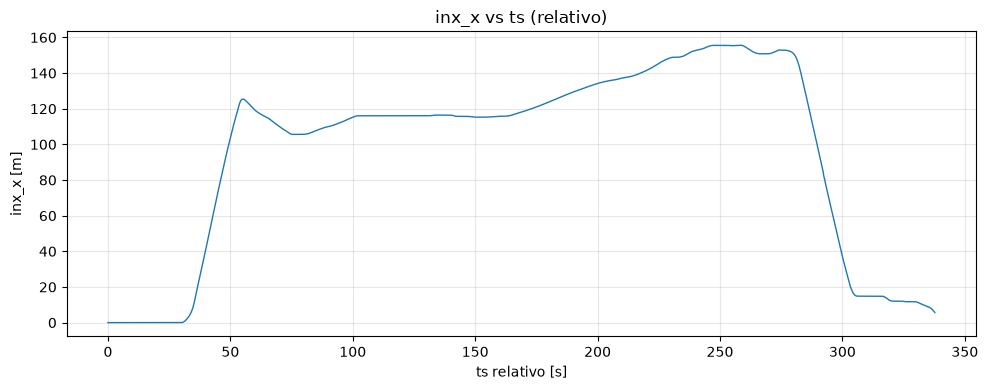

In [420]:
import matplotlib.pyplot as plt

# ts relativo en segundos (1 unidad de ts ~ 1 ms)
t_rel = (df_log["ts"] - df_log["ts"].iloc[0]) / 1000.0

# 1) inx_x vs ts (relativo)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_rel, df_log["inx_x"], lw=1)
ax.set_xlabel("ts relativo [s]")
ax.set_ylabel("inx_x [m]")
ax.set_title("inx_x vs ts (relativo)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

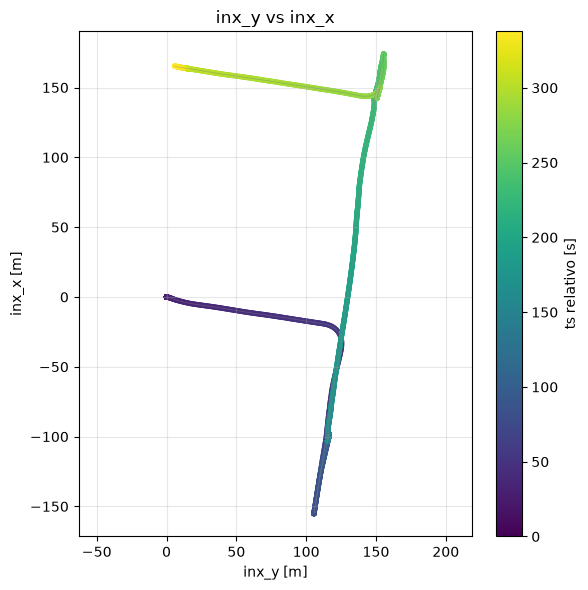

In [421]:
# 2) inx_x vs inx_y (trayectoria en el plano local del INS)
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(df_log["inx_x"], df_log["inx_y"], c=t_rel, cmap="viridis", s=8)
ax.plot(df_log["inx_x"], df_log["inx_y"], lw=0.5, color="gray", alpha=0.5)
ax.set_xlabel("inx_y [m]")
ax.set_ylabel("inx_x [m]")
ax.set_title("inx_y vs inx_x")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label="ts relativo [s]")
plt.tight_layout()
plt.show()

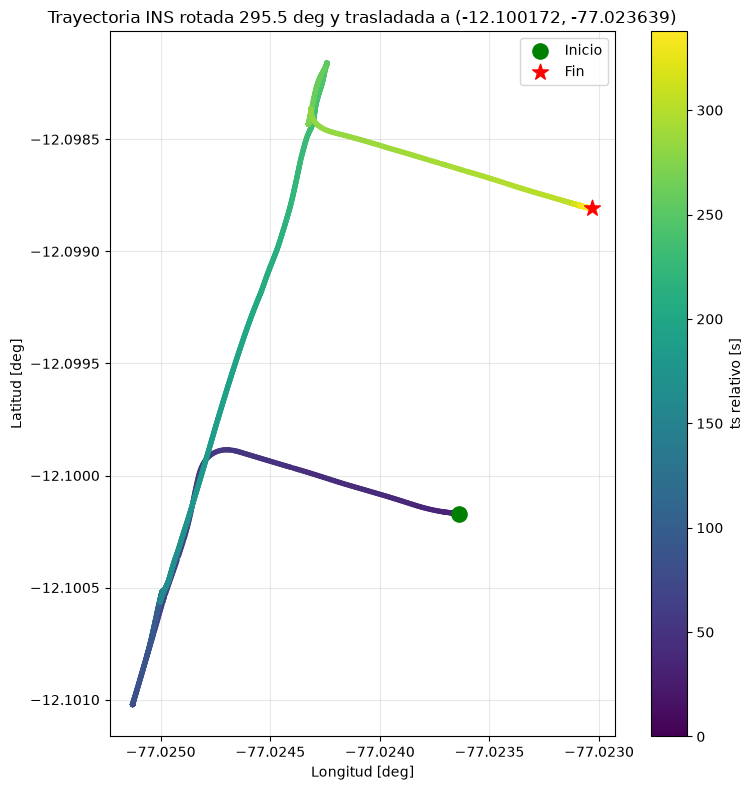

In [422]:
# Trayectoria INS rotada 295.5 respecto al Norte y trasladada al punto inicial (lat/lon)
import numpy as np

# 1) Rotacion NED por el heading del beacon (295.5 sobre el Norte) -> offsets Este/Norte [m]
PSI = 295.5
r = np.radians(PSI)
# est_E = df_log["inx_x"] * np.sin(r) - df_log["inx_y"] * np.cos(r)   # Este  [m]
# est_N = df_log["inx_x"] * np.cos(r) + df_log["inx_y"] * np.sin(r)   # Norte [m]

est_N = df_log["inx_x"] * np.cos(r) - df_log["inx_y"] * np.sin(r)   # Norte [m]
est_E = df_log["inx_x"] * np.sin(r) + df_log["inx_y"] * np.cos(r)   # Este  [m]

# 2) Traslacion: punto inicial en lat/lon (IBeacon) + offsets en metros -> lat/lon
lat0, lon0 = -12.100172, -77.023639
M_PER_DEG_LAT = 111320.0
lat = lat0 + est_N / M_PER_DEG_LAT
lon = lon0 + est_E / (M_PER_DEG_LAT * np.cos(np.radians(lat0)))

# 3) Plot lon (X) vs lat (Y)
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(lon, lat, c=t_rel, cmap="viridis", s=8, zorder=2)
ax.plot(lon, lat, lw=0.5, color="gray", alpha=0.5, zorder=1)

ax.scatter(lon.iloc[0],  lat.iloc[0],  color="green", s=120, marker="o", zorder=3, label="Inicio")
ax.scatter(lon.iloc[-1], lat.iloc[-1], color="red",   s=140, marker="*", zorder=3, label="Fin")

ax.set_xlabel("Longitud [deg]")
ax.set_ylabel("Latitud [deg]")
ax.set_title(f"Trayectoria INS rotada {PSI} deg y trasladada a ({lat0}, {lon0})")
ax.set_aspect(1 / np.cos(np.radians(lat0)))   # metros iguales se ven iguales
ax.ticklabel_format(useOffset=False, style="plain")
ax.grid(True, alpha=0.3)
ax.legend()
fig.colorbar(sc, ax=ax, label="ts relativo [s]")
plt.tight_layout()
plt.show()

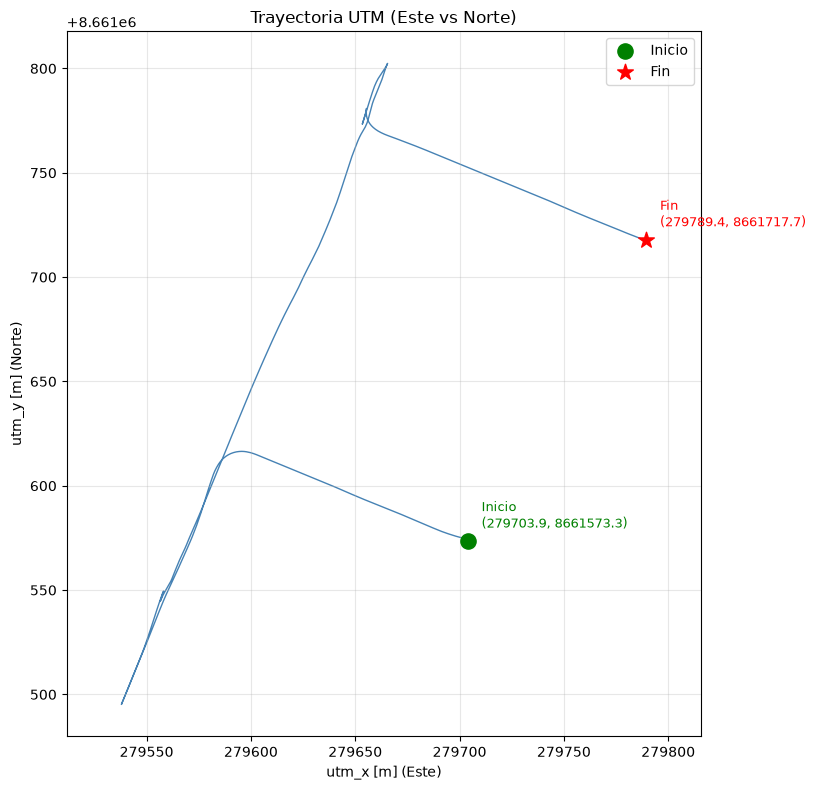

In [423]:
# Trayectoria UTM con identificadores de inicio y fin
# utm_x = Este (Easting, ~279717), utm_y = Norte (Northing, ~8661585)
# Mapa correcto: Este en el eje X, Norte en el eje Y
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(df_log["utm_x"], df_log["utm_y"], lw=1, color="steelblue", zorder=1)

# Punto inicial y final
x0, y0 = df_log["utm_x"].iloc[0],  df_log["utm_y"].iloc[0]
xf, yf = df_log["utm_x"].iloc[-1], df_log["utm_y"].iloc[-1]

ax.scatter(x0, y0, color="green", s=120, marker="o", zorder=3, label="Inicio")
ax.scatter(xf, yf, color="red",   s=140, marker="*", zorder=3, label="Fin")

ax.annotate(f"Inicio\n({x0:.1f}, {y0:.1f})", (x0, y0),
            textcoords="offset points", xytext=(10, 10), color="green", fontsize=9)
ax.annotate(f"Fin\n({xf:.1f}, {yf:.1f})", (xf, yf),
            textcoords="offset points", xytext=(10, 10), color="red", fontsize=9)

ax.set_xlabel("utm_x [m] (Este)")
ax.set_ylabel("utm_y [m] (Norte)")
ax.set_title("Trayectoria UTM (Este vs Norte)")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [424]:
import numpy as np
np.sqrt((278821.8 - 279717.5) **2 + (8661997.3 - 8661568.1)**2)

np.float64(993.2225984143636)

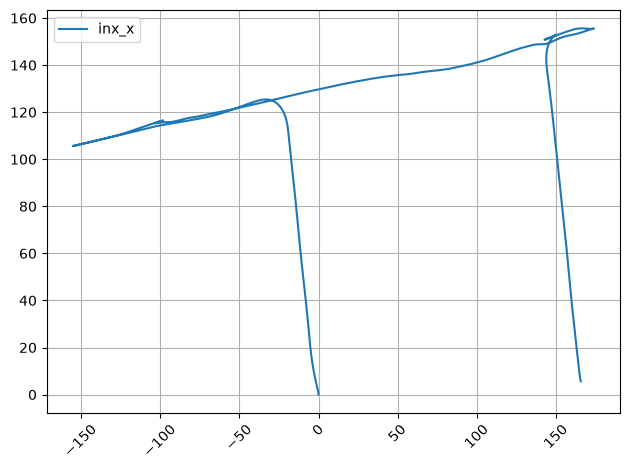

In [425]:
plot_window(df_log, ts_array="inx_y", data_array="inx_x")

In [426]:
# Trayectoria sobre un mapa real (folium / OpenStreetMap)
# Usa lat/lon calculados en la celda de rotacion+traslacion (825...)
import folium

coords = list(zip(lat, lon))

# Mapa centrado en el punto inicial
m = folium.Map(location=[lat0, lon0], zoom_start=18, tiles="OpenStreetMap")

# Linea de la trayectoria
folium.PolyLine(coords, color="blue", weight=3, opacity=0.8,
                tooltip="Trayectoria INS").add_to(m)

# Marcadores inicio / fin
folium.Marker([lat.iloc[0], lon.iloc[0]], tooltip="Inicio",
              icon=folium.Icon(color="green", icon="play")).add_to(m)
folium.Marker([lat.iloc[-1], lon.iloc[-1]], tooltip="Fin",
              icon=folium.Icon(color="red", icon="stop")).add_to(m)

# Punto del beacon (origen)
folium.CircleMarker([lat0, lon0], radius=5, color="black", fill=True,
                    fill_opacity=1, tooltip="Beacon (origen)").add_to(m)

# Ajusta el zoom para que quepa toda la trayectoria
m.fit_bounds(coords)

# Guarda una copia en HTML (por si se quiere abrir aparte) y muestra inline
m.save("trayectoria_mapa.html")
m

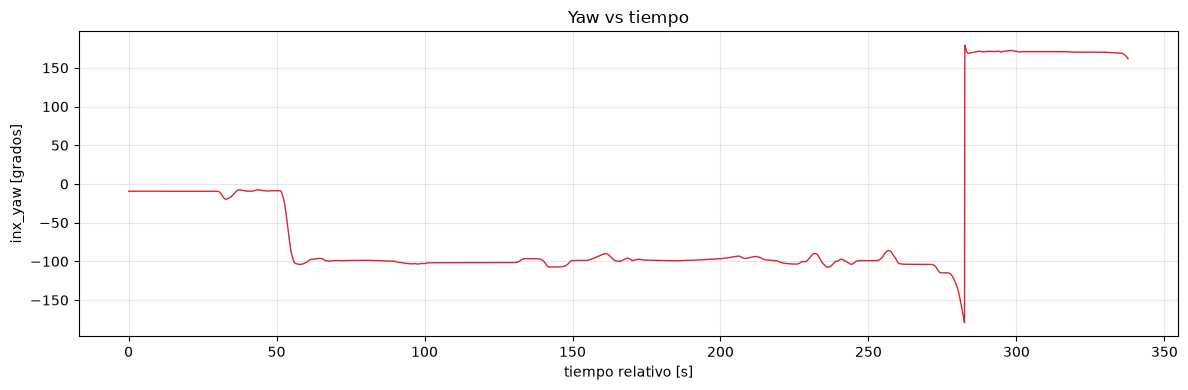

In [427]:
# yaw (inx_yaw) vs tiempo
# ts relativo en segundos (1 unidad de ts ~ 1 ms)
t_rel = (df_log["ts"] - df_log["ts"].iloc[0]) / 1000.0

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_rel, df_log["inx_yaw"], lw=1, color="tab:red")
ax.set_xlabel("tiempo relativo [s]")
ax.set_ylabel("inx_yaw [grados]")
ax.set_title("Yaw vs tiempo")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

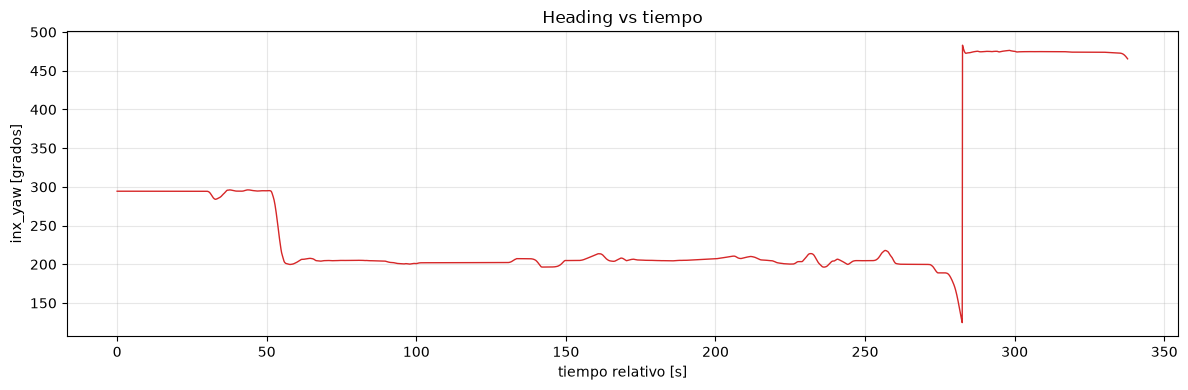

In [428]:
t_rel = (df_log["ts"] - df_log["ts"].iloc[0]) / 1000.0

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_rel, df_log["heading"], lw=1, color="tab:red")
ax.set_xlabel("tiempo relativo [s]")
ax.set_ylabel("inx_yaw [grados]")
ax.set_title("Heading vs tiempo")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()